# Prepare exposure & vulnerability layers 

**Purpose:** Convert raw inputs from previous notebook into **static GeoTIFFs** aligned to the daily hazard grid. This is the expensive preprocessing step — run **once** when exposure/vulnerability sources or the hazard grid change.

**Conceptual framing:** These layers measure *what could be affected* (exposure) and *who may be more sensitive* (vulnerability). They are **not** wildfire probability. Operational priority is computed later in through a **rule-based** framework (`plan/rule_based_risk.md`), not as `hazard × exposure × vulnerability`.

**Inputs (from notebook 03):**

| Input | Path |
|-------|------|
| Population (GHSL 2030) | `exposure/population.tif` |
| Buildings | `exposure/buildings.geojson` |
| Roads | `exposure/roads.geojson` |
| Critical amenities | `exposure/amenities.geojson` |
| Municipality vulnerability | `vulnerability/municipalities_vulnerability.geojson` |

**Grid reference:** Any hazard GeoTIFF from `risk_maps/` (produced in `02_hazard_maps`). All outputs share its CRS, resolution, extent and transform.

**Outputs → `risk_layers/`:**

| File | Values | Used in 06 |
|------|--------|------------|
| `exposure_population_aligned.tif` | continuous 0–1 | Population component |
| `exposure_assets_aligned.tif` | continuous 0–1 | Weighted OSM assets |
| `exposure_total.tif` | continuous 0–1 | Combined exposure |
| `vulnerability_aligned.tif` | continuous 0–1 | Municipality income vulnerability |
| `exposure_class.tif` | ordinal 0–4 | Rule input |
| `vulnerability_class.tif` | ordinal 0–1 | Rule input |

## Configuration

Configurable paths and weights at the top of the notebook. The **hazard GeoTIFF** is the spatial reference for every output raster.

### Weighting scheme

**Asset exposure** (vector layers rasterised per grid cell):
- Buildings: **0.4**
- Roads: **0.3**
- Critical amenities: **0.3**

**Total exposure:**
```text
exposure_total = 0.6 × population_norm + 0.4 × asset_exposure
```

If a vector layer is missing or empty, weighted_combine() redistributes weights among the remaining layers (no hard failure).

### Vulnerability field
income_vulnerability from notebook 04:

0 = lower socioeconomic vulnerability (higher municipal income)
1 = higher vulnerability (lower income)

In [1]:
from pathlib import Path

PROJECT_ROOT = Path(".").resolve()

RISK_MAPS_DIR = PROJECT_ROOT / "../data/risk_maps"
GRID_TEMPLATE_DATE = "2025-08-15"  # any date with same grid as hazard stack
GRID_TEMPLATE_PATH = RISK_MAPS_DIR / f"{GRID_TEMPLATE_DATE}.tif"

POPULATION_RASTER_PATH = PROJECT_ROOT / "../data/exposure/population.tif"
BUILDINGS_VECTOR_PATH = PROJECT_ROOT / "../data/exposure/buildings.geojson"
ROADS_VECTOR_PATH = PROJECT_ROOT / "../data/exposure/roads.geojson"
CRITICAL_ASSETS_VECTOR_PATH = PROJECT_ROOT / "../data/exposure/amenities.geojson"

MUNICIPALITY_VULNERABILITY_PATH = PROJECT_ROOT / "../data/vulnerability/municipalities_vulnerability.geojson"
VULNERABILITY_FIELD = "income_vulnerability"

AOI_VECTOR_PATH = PROJECT_ROOT / "../data/aois/seadur.geojson"
OUTPUT_DIR = PROJECT_ROOT / "../data/risk_layers"

ASSET_WEIGHTS = {"buildings": 0.4, "roads": 0.3, "critical": 0.3}
EXPOSURE_WEIGHTS = {"population": 0.6, "assets": 0.4}

## Imports

Uses `classify_dimension()` from [`risk_priority.py`](../risk_priority.py) to convert continuous rasters to **ordinal classes** with the same thresholds used for hazard in notebook 06:

| Class | Continuous range |
|-------|------------------|
| 0 | No data |
| 1 | Low — [0.00, 0.25) |
| 2 | Medium — [0.25, 0.50) |
| 3 | High — [0.50, 0.75) |
| 4 | Critical — [0.75, 1.00] |

These ordinals are **inputs to the rule matrix** in 06 — hazard, exposure and vulnerability are treated as qualitatively different dimensions, not multiplied as comparable continuous scores.

In [3]:
import logging
from typing import Optional

import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from rasterio import features, mask as rio_mask
from rasterio.enums import MergeAlg
from rasterio.warp import Resampling, reproject
from shapely.geometry import mapping

from risk_priority import classify_dimension

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
log = logging.getLogger("prepare_layers")

## Helper functions

Building blocks aligned with the pipeline plan. Each function handles one transformation step so the main pipeline (below) reads as a linear workflow.

| Function | Role |
|----------|------|
| `validate_paths` | Fail fast if required inputs from notebook 04 are missing |
| `read_grid_template` | Read CRS, transform, shape from hazard GeoTIFF |
| `reproject_to_grid` | Warp population raster to hazard grid (bilinear resampling) |
| `apply_aoi_mask` | Set pixels outside the AOI polygon to NoData |
| `normalise_array` | Scale to [0, 1] using 95th percentile (robust to outliers) |
| `rasterize_vector` | Convert OSM polygons/lines to per-cell presence/count |
| `weighted_combine` | Weighted sum with automatic weight renormalisation |
| `rasterize_vulnerability` | Assign each cell the `income_vulnerability` of its municipality |
| `write_raster` / `write_class_raster` | Save float32 continuous or uint8 ordinal GeoTIFFs |

In [4]:
def validate_paths(paths: list[Path]) -> None:
    missing = [p for p in paths if not Path(p).exists()]
    if missing:
        raise FileNotFoundError(f"Missing files: {missing}")


def read_grid_template(path: Path):
    """Read reference grid metadata from a hazard GeoTIFF."""
    with rasterio.open(path) as src:
        profile = src.profile.copy()
        transform = src.transform
        crs = src.crs
        shape = (src.height, src.width)
    profile.update(dtype="float32", nodata=np.nan, count=1, crs=crs)
    log.info("Grid template: %s | shape=%s | crs=%s", path.name, shape, crs)
    return profile, transform, crs, shape


def write_class_raster(path: Path, classes: np.ndarray, profile: dict) -> None:
    """Write uint8 ordinal class raster (0 = No data)."""
    out_profile = profile.copy()
    out_profile.update(dtype="uint8", nodata=0, compress="lzw")
    path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(path, "w", **out_profile) as dst:
        dst.write(classes.astype(np.uint8), 1)
    log.info("Wrote %s", path)


def write_raster(path: Path, array: np.ndarray, profile: dict, nodata: float = np.nan) -> None:
    out_profile = profile.copy()
    out_profile.update(
        driver="GTiff",
        dtype="float32",
        nodata=nodata,
        compress="lzw",
    )
    path.parent.mkdir(parents=True, exist_ok=True)
    data = np.where(np.isfinite(array), array, nodata).astype(np.float32)
    with rasterio.open(path, "w", **out_profile) as dst:
        dst.write(data, 1)
    log.info("Wrote %s", path)


def reproject_to_grid(src_path: Path, transform, crs, shape: tuple[int, int]) -> np.ndarray:
    height, width = shape
    dst = np.full((height, width), np.nan, dtype=np.float32)
    with rasterio.open(src_path) as src:
        src_data = src.read(1).astype(np.float32)
        if src.nodata is not None:
            src_data = np.where(src_data == src.nodata, np.nan, src_data)
        reproject(
            source=src_data,
            destination=dst,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=crs,
            resampling=Resampling.bilinear,
            src_nodata=np.nan,
            dst_nodata=np.nan,
        )
    return dst


def apply_aoi_mask(array: np.ndarray, profile: dict, aoi_gdf: gpd.GeoDataFrame) -> np.ndarray:
    if aoi_gdf is None or aoi_gdf.empty:
        return array
    aoi = aoi_gdf.to_crs(profile["crs"])
    geoms = [mapping(g) for g in aoi.geometry if g is not None and not g.is_empty]
    with rasterio.io.MemoryFile() as memfile:
        with memfile.open(**profile) as tmp:
            tmp.write(np.where(np.isfinite(array), array, np.nan), 1)
            masked, _ = rio_mask.mask(tmp, geoms, crop=False, nodata=np.nan, filled=True)
    return masked[0].astype(np.float32)


def normalise_array(array: np.ndarray, valid_mask: Optional[np.ndarray] = None, quantile: float = 95) -> np.ndarray:
    """Robust [0, 1] scaling using the 95th percentile."""
    arr = array.astype(np.float32)
    mask = valid_mask if valid_mask is not None else np.isfinite(arr) & (arr > 0)
    if not np.any(mask):
        return np.zeros_like(arr, dtype=np.float32)
    scale = float(np.nanpercentile(arr[mask], quantile))
    if scale <= 0:
        scale = float(np.nanmax(arr[mask])) or 1.0
    return np.clip(arr / scale, 0, 1).astype(np.float32)


def rasterize_vector(vector_path: Path, transform, shape, crs, merge_alg: str = "add") -> Optional[np.ndarray]:
    path = Path(vector_path)
    if not path.exists():
        log.warning("Optional layer missing: %s", path)
        return None
    gdf = gpd.read_file(path)
    if gdf.empty:
        log.warning("Empty layer: %s", path)
        return None
    gdf = gdf.to_crs(crs)
    shapes = ((g, 1.0) for g in gdf.geometry if g is not None and not g.is_empty)
    alg = MergeAlg.add if merge_alg == "add" else MergeAlg.replace
    return features.rasterize(
        shapes,
        out_shape=shape,
        transform=transform,
        fill=0,
        dtype=np.float32,
        merge_alg=alg,
    ).astype(np.float32)


def weighted_combine(layers: list[tuple[Optional[np.ndarray], float]], shape) -> np.ndarray:
    active = [(a, w) for a, w in layers if a is not None]
    if not active:
        return np.zeros(shape, dtype=np.float32)
    total_w = sum(w for _, w in active)
    out = sum(a * (w / total_w) for a, w in active)
    return np.clip(out, 0, 1).astype(np.float32)


def rasterize_vulnerability(vector_path: Path, field: str, transform, shape, crs) -> np.ndarray:
    gdf = gpd.read_file(vector_path).to_crs(crs)
    shapes = (
        (geom, float(val))
        for geom, val in zip(gdf.geometry, gdf[field])
        if geom is not None and not geom.is_empty and pd.notna(val)
    )
    # Cells outside municipality polygons → 0 (documented choice for MVP).
    return features.rasterize(
        shapes, out_shape=shape, transform=transform, fill=0, dtype=np.float32, merge_alg=MergeAlg.replace
    ).astype(np.float32)

## Build layers

End-to-end pipeline. 

### Step 1 — Reference grid
Read metadata from one hazard GeoTIFF. Every output raster inherits the same pixel grid as `data/risk_maps/{date}.tif`.

### Step 2 — Population exposure
1. Reproject `population.tif` (WGS84 from notebook 04) → hazard CRS/resolution  
2. Mask to AOI polygon (`seadur.geojson`)  
3. Normalise positive cells with 95th percentile → `[0, 1]`  
4. Save `exposure_population_aligned.tif`

### Step 3 — Asset exposure
1. Rasterise buildings, roads and critical amenities (OSM vectors from notebook 04)  
2. Normalise each layer to `[0, 1]` independently  
3. Weighted combine (0.4 / 0.3 / 0.3) → `exposure_assets_aligned.tif`

Buildings, roads and amenities are **exposure** (what is at risk), not vulnerability.

### Step 4 — Total exposure
```text
exposure_total = clip(0.6 × population_norm + 0.4 × asset_exposure, 0, 1)

In [5]:

validate_paths(
    [
        GRID_TEMPLATE_PATH,
        POPULATION_RASTER_PATH,
        MUNICIPALITY_VULNERABILITY_PATH,
        AOI_VECTOR_PATH,
    ]
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

profile, transform, crs, shape = read_grid_template(GRID_TEMPLATE_PATH)
aoi = gpd.read_file(AOI_VECTOR_PATH)

# Population exposure
population = reproject_to_grid(POPULATION_RASTER_PATH, transform, crs, shape)
population = apply_aoi_mask(population, profile, aoi)
population_norm = normalise_array(population, np.isfinite(population) & (population > 0))
pop_path = OUTPUT_DIR / "exposure_population_aligned.tif"
write_raster(pop_path, population_norm, profile)

# Asset exposure
asset_layers = [
    (rasterize_vector(BUILDINGS_VECTOR_PATH, transform, shape, crs), ASSET_WEIGHTS["buildings"]),
    (rasterize_vector(ROADS_VECTOR_PATH, transform, shape, crs), ASSET_WEIGHTS["roads"]),
    (rasterize_vector(CRITICAL_ASSETS_VECTOR_PATH, transform, shape, crs), ASSET_WEIGHTS["critical"]),
]
asset_norms = [(normalise_array(a, a > 0) if a is not None else None, w) for a, w in asset_layers]
assets = weighted_combine(asset_norms, shape)
assets_path = OUTPUT_DIR / "exposure_assets_aligned.tif"
write_raster(assets_path, assets, profile)

pw, aw = EXPOSURE_WEIGHTS["population"], EXPOSURE_WEIGHTS["assets"]
exposure_total = np.clip(pw * population_norm + aw * assets, 0, 1).astype(np.float32)
exposure_path = OUTPUT_DIR / "exposure_total.tif"
write_raster(exposure_path, exposure_total, profile)

# Vulnerability
vulnerability = rasterize_vulnerability(
    MUNICIPALITY_VULNERABILITY_PATH, VULNERABILITY_FIELD, transform, shape, crs
)
vulnerability = np.clip(vulnerability, 0, 1)
vuln_path = OUTPUT_DIR / "vulnerability_aligned.tif"
write_raster(vuln_path, vulnerability, profile)

# Ordinal classes for rule-based priority (see plan/rule_based_risk.md)
exposure_cls = classify_dimension(exposure_total)
exposure_class_path = OUTPUT_DIR / "exposure_class.tif"
write_class_raster(exposure_class_path, exposure_cls, profile)

vulnerability_cls = classify_dimension(vulnerability)
vulnerability_class_path = OUTPUT_DIR / "vulnerability_class.tif"
write_class_raster(vulnerability_class_path, vulnerability_cls, profile)

outputs = {
    "exposure_population_aligned": pop_path,
    "exposure_assets_aligned": assets_path,
    "exposure_total": exposure_path,
    "exposure_class": exposure_class_path,
    "vulnerability_aligned": vuln_path,
    "vulnerability_class": vulnerability_class_path,
}
for name, path in outputs.items():
    log.info("%s → %s", name, path)

INFO: Grid template: 2025-08-15.tif | shape=(1986, 3444) | crs=EPSG:4326
INFO: Wrote /home/fran/grand-marathon-mvp/data/risk_layers/exposure_population_aligned.tif
INFO: Wrote /home/fran/grand-marathon-mvp/data/risk_layers/exposure_assets_aligned.tif
INFO: Wrote /home/fran/grand-marathon-mvp/data/risk_layers/exposure_total.tif
INFO: Wrote /home/fran/grand-marathon-mvp/data/risk_layers/vulnerability_aligned.tif
INFO: Wrote /home/fran/grand-marathon-mvp/data/risk_layers/exposure_class.tif
INFO: Wrote /home/fran/grand-marathon-mvp/data/risk_layers/vulnerability_class.tif
INFO: exposure_population_aligned → /home/fran/grand-marathon-mvp/data/risk_layers/exposure_population_aligned.tif
INFO: exposure_assets_aligned → /home/fran/grand-marathon-mvp/data/risk_layers/exposure_assets_aligned.tif
INFO: exposure_total → /home/fran/grand-marathon-mvp/data/risk_layers/exposure_total.tif
INFO: exposure_class → /home/fran/grand-marathon-mvp/data/risk_layers/exposure_class.tif
INFO: vulnerability_align

## Visual QA

Quick sanity check before running notebook **06**:

- **`exposure_total`** — higher values where population and built assets overlap (towns, roads, amenities)
- **`exposure_class` / `vulnerability_class`** — ordinal values 1–4 inside the AOI; 0 = background/NoData
- **Patterns** should be spatially coherent with the Larouco–Seadur perimeter

If rasters look empty or uniform, re-check notebook 04 inputs and that `GRID_TEMPLATE_PATH` matches the hazard stack grid.

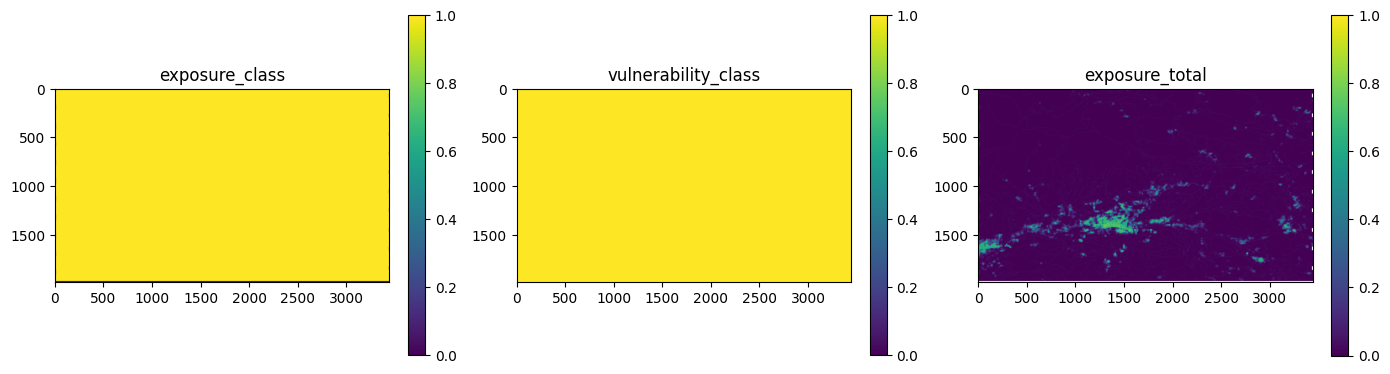

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, name in zip(axes, ["exposure_class", "vulnerability_class", "exposure_total"]):
  with rasterio.open(OUTPUT_DIR / f"{name}.tif") as src:
    data = src.read(1)
  im = ax.imshow(data, vmin=0, vmax=1, cmap="viridis")
  ax.set_title(name)
  plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()